# TRABAJO SEMANAL 4: PRIMERAS NOCIONES DE LA ESTIMACIÓN ESPECTRAL
## ALUMNA: Maylen Monterde
### INTRODUCCIÓN:

En el procesamiento digital de señales, uno de los problemas centrales es estimar los parámetros de una señal a partir de un número finito de muestras contaminadas con ruido. El objetivo de este trabajo es estimar la amplitud y la frecuencia de una senoidal contaminada con ruido, usando distintas ventanas espectrales y analizar cómo la elección de la ventana afecta la calidad de esos estimadores.

La señal que se utilizará está definida como: 
$$x(n) = a_0\cdot sen(\Omega_1\cdot n) + n_a(n)$$
donde $a_0$ es la amplitud, $\Omega_1$ es la frecuencia angular normalizada (que varía aleatoriamente alrededor de un valor nominal $\Omega_0=\pi/2$ según $\Omega_1 = \Omega_0 + f_r\cdot 2\pi/N$, con $f_r \sim U(-2,2)$ ) y $n_a(n)$ es el ruido gaussiano cuya potencia se ajusta según la relación señal-ruido (SNR) deseada. 

Se diseñan e implementan dos estimadores: uno de amplitud, basado en el módulo de la DFT evaluado en $\Omega_0$, y uno de frecuencia, basado en la ubicación del máximo del espectro. Ambos estimadores se evalúan bajo cuatro ventanas espectrales distintas (rectangular, flattop, Blackman-Harris y triangular), con el objetivo de analizar cómo la elección de la ventana afecta el sesgo y la varianza de cada estimador.

Para evaluar qué tan bueno es el estimador, se repite el experimento 200 veces (con distintas realizaciones aleatorias de la frecuencia y del ruido) y se calcula el sesgo (mide si el estimador acierta en 'promedio' al valor real o si sistemáticamente se corre para un lado) y la varianza (que mide cuánto varían las estimaciones individuales entre sí). Un buen estimador debería tener ambos valores lo más chicos posibles.

Adicionalmente, se incluye un análisis del efecto del zero-padding sobre la varianza del estimador de frecuencia, como complemento al estudio principal.


### RESOLUCIÓN:
1- Llamo a las librerías, defino mis variables y genero los vectores para generar una matriz (y trabajar con ella).

In [30]:
#%% LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as ssw

#%% PARÁMETROS GENERALES
Ps = 1 # potencia de la senoidal (normalizada a 1W)
A = np.sqrt(2*Ps) #amplitud del seno
Vmed = 0
phi = 0
N = 1000
R = 200 # realizaciones
fs = 1000
deltaf = 2*np.pi/N # ancho de un bin en rad/muestra
omega0 = np.pi/2

#%% CREO LOS VECTORES
n = np.arange(N)
fr = np.random.uniform(-2,2,R) # la distribución que me dan
columna_n = n.reshape((N,1))
fila_fr = fr.reshape((1,R))

#%% DOMINIO DE FRECUENCIAS
frecuencias = np.fft.fftfreq(N, 1/fs)
corte = N // 2
frec_nyquist = frecuencias[:corte]

2- Genero las distintas ventanas que se van a utilizar

In [31]:
#%% VENTANEAR
w1 = ssw.get_window('boxcar', N)
w2 = ssw.get_window('flattop', N)
w3 = ssw.get_window('blackmanharris', N)
w4 = ssw.get_window('triang', N)

3- Genero una función donde calcula los estimadores para los distintos SNR. En este caso se analiza para $SNR=3$ y $SNR=10$

In [32]:
#%% FUNCIÓN ANALIZA PARA DISTINTOS SNR
def experimento(SNR):
    
    omega1 = omega0 + (fila_fr * deltaf) 
    matriz_fase = columna_n * omega1
    x_seno = A*np.sin(matriz_fase)
    
    Pruido = 10 ** (-SNR / 10 + np.log10(Ps))
    sigma = np.sqrt(Pruido)
    na_r = np.random.normal(0, sigma, (N, R))
    
    xn = x_seno + na_r
    
    # ventaneo
    ventana1 = xn*w1[:, None]
    ventana2 = xn*w2[:, None]
    ventana3 = xn*w3[:, None]
    ventana4 = xn*w4[:, None]
    
    fft1 = np.fft.fft(ventana1, axis=0) / np.sum(w1)
    fft2 = np.fft.fft(ventana2, axis=0) / np.sum(w2)
    fft3 = np.fft.fft(ventana3, axis=0) / np.sum(w3)
    fft4 = np.fft.fft(ventana4, axis=0) / np.sum(w4)
    
    modulo1 = np.abs(fft1)
    modulo2 = np.abs(fft2)
    modulo3 = np.abs(fft3)
    modulo4 = np.abs(fft4)
    
    # estimador de amplitud
    a1 = 2 * modulo1[N//4, :]
    a2 = 2 * modulo2[N//4, :]
    a3 = 2 * modulo3[N//4, :]
    a4 = 2 * modulo4[N//4, :]
    
    A_real = A
    sesgo_a1 = np.mean(a1) - A_real
    sesgo_a2 = np.mean(a2) - A_real
    sesgo_a3 = np.mean(a3) - A_real
    sesgo_a4 = np.mean(a4) - A_real
    
    varianza_a1 = np.var(a1)
    varianza_a2 = np.var(a2)
    varianza_a3 = np.var(a3)
    varianza_a4 = np.var(a4)
    
    # estimador de frecuencia
    corte = N // 2
    f1 = np.argmax(modulo1[:corte, :], axis=0)
    f2 = np.argmax(modulo2[:corte, :], axis=0)
    f3 = np.argmax(modulo3[:corte, :], axis=0)
    f4 = np.argmax(modulo4[:corte, :], axis=0)
    
    f1_rad = 2 * np.pi * f1 / N
    f2_rad = 2 * np.pi * f2 / N
    f3_rad = 2 * np.pi * f3 / N
    f4_rad = 2 * np.pi * f4 / N
    
    omega1_real_medio = np.mean(omega1)
    
    sesgo_f1 = np.mean(f1_rad) - omega1_real_medio
    sesgo_f2 = np.mean(f2_rad) - omega1_real_medio
    sesgo_f3 = np.mean(f3_rad) - omega1_real_medio
    sesgo_f4 = np.mean(f4_rad) - omega1_real_medio
    
    varianza_f1 = np.var(f1_rad)
    varianza_f2 = np.var(f2_rad)
    varianza_f3 = np.var(f3_rad)
    varianza_f4 = np.var(f4_rad)
    """
    print(f"--- SNR = {SNR} dB ---")
    print(f"Ventana 1 (Boxcar)                -> Sesgo: {sesgo_a1:.5f} | Varianza: {varianza_a1:.5f}")
    print(f"Ventana 2 (Flattop)               -> Sesgo: {sesgo_a2:.5f} | Varianza: {varianza_a2:.5f}")
    print(f"Ventana 3 (Blackman-H.)           -> Sesgo: {sesgo_a3:.5f} | Varianza: {varianza_a3:.5f}")
    print(f"Ventana 4 (Triang)                -> Sesgo: {sesgo_a4:.5f} | Varianza: {varianza_a4:.5f}")
    print(f"Ventana 1 (Boxcar) frecuencia     -> Sesgo: {sesgo_f1:.5f} | Varianza: {varianza_f1:.5f}")
    print(f"Ventana 2 (Flattop) frecuencia    -> Sesgo: {sesgo_f2:.5f} | Varianza: {varianza_f2:.5f}")
    print(f"Ventana 3 (Blackman-H.) frecuencia-> Sesgo: {sesgo_f3:.5f} | Varianza: {varianza_f3:.5f}")
    print(f"Ventana 4 (Triang) frecuencia     -> Sesgo: {sesgo_f4:.5f} | Varianza: {varianza_f4:.5f}")
    """
    return {
        'a1': a1, 'a2': a2, 'a3': a3, 'a4': a4,
        'f1_rad': f1_rad, 'f2_rad': f2_rad, 'f3_rad': f3_rad, 'f4_rad': f4_rad,
        'sesgo_a1': sesgo_a1, 'sesgo_a2': sesgo_a2, 'sesgo_a3': sesgo_a3, 'sesgo_a4': sesgo_a4,
        'varianza_a1': varianza_a1, 'varianza_a2': varianza_a2, 'varianza_a3': varianza_a3, 'varianza_a4': varianza_a4,
        'sesgo_f1': sesgo_f1, 'sesgo_f2': sesgo_f2, 'sesgo_f3': sesgo_f3, 'sesgo_f4': sesgo_f4,
        'varianza_f1': varianza_f1, 'varianza_f2': varianza_f2, 'varianza_f3': varianza_f3, 'varianza_f4': varianza_f4,
    }

#%% LLAMADAS PARA CADA SNR
resultados_3db = experimento(3)
resultados_10db = experimento(10)

4- Grafico histograma de cada estimador para los distintos SNR:

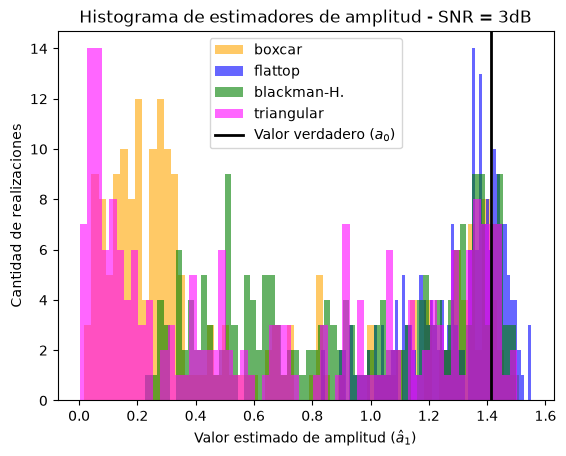

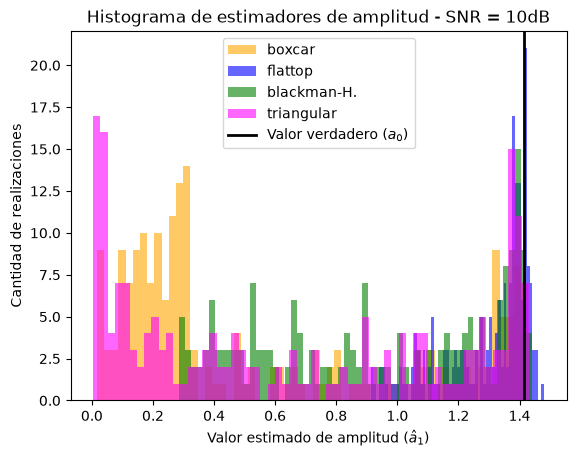

In [33]:
#%% HISTOGRAMA DE AMPLITUD - SNR = 3dB
plt.figure()
plt.hist(resultados_3db['a1'], bins=60, label='boxcar', color='orange', alpha=0.6, linewidth=4)
plt.hist(resultados_3db['a2'], bins=60, label='flattop', color='blue', alpha=0.6, linewidth=4)
plt.hist(resultados_3db['a3'], bins=60, label='blackman-H.', color='green', alpha=0.6, linewidth=4)
plt.hist(resultados_3db['a4'], bins=60, label='triangular', color='magenta', alpha=0.6, linewidth=4)
plt.axvline(A, color='black', linestyle='-', linewidth=2, label='Valor verdadero ($a_0$)')
plt.title("Histograma de estimadores de amplitud - SNR = 3dB")
plt.xlabel("Valor estimado de amplitud ($\hat{a}_1$)")
plt.ylabel("Cantidad de realizaciones")
plt.legend()

#%% HISTOGRAMA DE AMPLITUD - SNR = 10dB
plt.figure()
plt.hist(resultados_10db['a1'], bins=60, label='boxcar', color='orange', alpha=0.6, linewidth=4)
plt.hist(resultados_10db['a2'], bins=60, label='flattop', color='blue', alpha=0.6, linewidth=4)
plt.hist(resultados_10db['a3'], bins=60, label='blackman-H.', color='green', alpha=0.6, linewidth=4)
plt.hist(resultados_10db['a4'], bins=60, label='triangular', color='magenta', alpha=0.6, linewidth=4)
plt.axvline(A, color='black', linestyle='-', linewidth=2, label='Valor verdadero ($a_0$)')
plt.title("Histograma de estimadores de amplitud - SNR = 10dB")
plt.xlabel("Valor estimado de amplitud ($\hat{a}_1$)")
plt.ylabel("Cantidad de realizaciones")
plt.legend()


En estos graficos se observa que la elección de la ventana afecta más en el resultado que el nivel del SNR. La ventana azul (Flattop) tiene sus estimaciones cerca del valor verdadero $a_0=\sqrt{2}$, mientras que la Boxcar y la triangular quedan corridas hacia los valores más bajos y con mayor dispersión. Esto explica porque la frecuencia real de la señal $\Omega_1$ rara vez cae justo en el bin nominal $\Omega_0$, sino que se desplaza debido al factor aleatorio $f_r$.

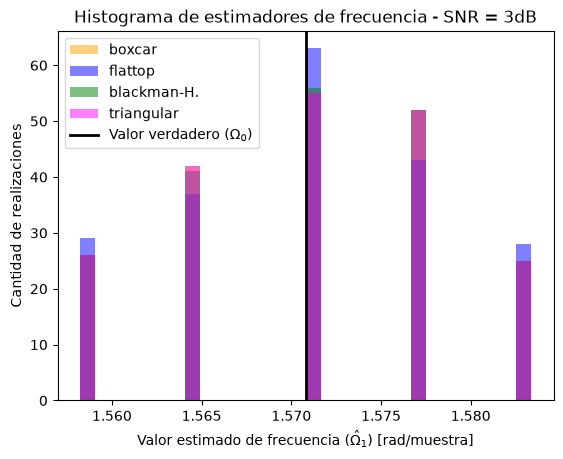

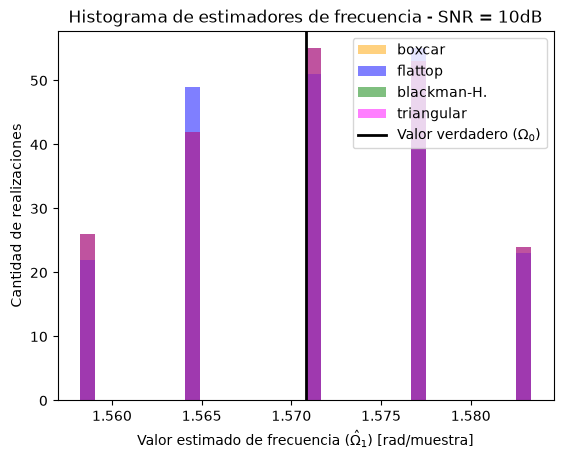

In [34]:
#%% HISTOGRAMA DE FRECUENCIA - SNR = 3dB
plt.figure()
plt.hist(resultados_3db['f1_rad'], bins=30, label='boxcar', color='orange', alpha=0.5, linewidth=4)
plt.hist(resultados_3db['f2_rad'], bins=30, label='flattop', color='blue', alpha=0.5, linewidth=4)
plt.hist(resultados_3db['f3_rad'], bins=30, label='blackman-H.', color='green', alpha=0.5, linewidth=4)
plt.hist(resultados_3db['f4_rad'], bins=30, label='triangular', color='magenta', alpha=0.5, linewidth=4)
plt.axvline(omega0, color='black', linestyle='-', linewidth=2, label='Valor verdadero ($\Omega_0$)')
plt.title("Histograma de estimadores de frecuencia - SNR = 3dB")
plt.xlabel("Valor estimado de frecuencia ($\hat{\Omega}_1$) [rad/muestra]")
plt.ylabel("Cantidad de realizaciones")
plt.legend()

#%% HISTOGRAMA DE FRECUENCIA - SNR = 10dB
plt.figure()
plt.hist(resultados_10db['f1_rad'], bins=30, label='boxcar', color='orange', alpha=0.5, linewidth=4)
plt.hist(resultados_10db['f2_rad'], bins=30, label='flattop', color='blue', alpha=0.5, linewidth=4)
plt.hist(resultados_10db['f3_rad'], bins=30, label='blackman-H.', color='green', alpha=0.5, linewidth=4)
plt.hist(resultados_10db['f4_rad'], bins=30, label='triangular', color='magenta', alpha=0.5, linewidth=4)
plt.axvline(omega0, color='black', linestyle='-', linewidth=2, label='Valor verdadero ($\Omega_0$)')
plt.title("Histograma de estimadores de frecuencia - SNR = 10dB")
plt.xlabel("Valor estimado de frecuencia ($\hat{\Omega}_1$) [rad/muestra]")
plt.ylabel("Cantidad de realizaciones")
plt.legend()

A diferencia de la amplitud, los histogramas de frecuencia son prácticamente idénticos entre las cuatro ventanas, y muestran una distribución discreta (agrupada en pocos valores posibles) en vez de continua. Esto se debe a que el estimador de frecuencia no depende de la forma de la ventana, sino de la resolución de la FFT que limita los valores posibles que puede devolver el estimador.

5- Armo una tabla para los distintos valores de sesgo y varianza obtenidos:

In [35]:
#%% TABLAS
import pandas as pd

def armar_tabla(resultados, tipo):
    
    ventanas = ['Rectangular', 'Flat-top', 'Blackman-H.', 'Triangular']
    sesgos = [resultados[f'sesgo_{tipo}1'], resultados[f'sesgo_{tipo}2'],
              resultados[f'sesgo_{tipo}3'], resultados[f'sesgo_{tipo}4']]
    varianzas = [resultados[f'varianza_{tipo}1'], resultados[f'varianza_{tipo}2'],
                 resultados[f'varianza_{tipo}3'], resultados[f'varianza_{tipo}4']]
    
    df = pd.DataFrame({
        'Ventana': ventanas,
        'sa' if tipo=='a' else 'sf': sesgos,
        'va' if tipo=='a' else 'vf': varianzas,
    })
    return df

print("=== ESTIMACIÓN DE AMPLITUD - SNR = 3dB ===")
tabla_amp_3db = armar_tabla(resultados_3db, 'a')
print(tabla_amp_3db.to_string(index=False))

print("\n=== ESTIMACIÓN DE FRECUENCIA - SNR = 3dB ===")
tabla_frec_3db = armar_tabla(resultados_3db, 'f')
print(tabla_frec_3db.to_string(index=False))

print("\n=== ESTIMACIÓN DE AMPLITUD - SNR = 10dB ===")
tabla_amp_10db = armar_tabla(resultados_10db, 'a')
print(tabla_amp_10db.to_string(index=False))

print("\n=== ESTIMACIÓN DE FRECUENCIA - SNR = 10dB ===")
tabla_frec_10db = armar_tabla(resultados_10db, 'f')
print(tabla_frec_10db.to_string(index=False))

=== ESTIMACIÓN DE AMPLITUD - SNR = 3dB ===
    Ventana        sa       va
Rectangular -0.848205 0.232470
   Flat-top -0.121323 0.027212
Blackman-H. -0.475236 0.150701
 Triangular -0.743459 0.275718

=== ESTIMACIÓN DE FRECUENCIA - SNR = 3dB ===
    Ventana        sf       vf
Rectangular -0.000007 0.000059
   Flat-top -0.000132 0.000061
Blackman-H.  0.000025 0.000059
 Triangular -0.000007 0.000059

=== ESTIMACIÓN DE AMPLITUD - SNR = 10dB ===
    Ventana        sa       va
Rectangular -0.851487 0.233130
   Flat-top -0.118890 0.020749
Blackman-H. -0.474988 0.142026
 Triangular -0.749586 0.275100

=== ESTIMACIÓN DE FRECUENCIA - SNR = 10dB ===
    Ventana        sf       vf
Rectangular -0.000038 0.000058
   Flat-top -0.000007 0.000056
Blackman-H. -0.000038 0.000058
 Triangular -0.000038 0.000058



Las tablas confirman lo observado en los histogramas: en amplitud, Flattop tiene el menor sesgo y menor varianza de las cuatro ventanas, mientras que boxcar y triangular presentan los peores valores. En frecuencia, en cambio, las cuatro ventanas dan resultados casi iguales, con sesgo y varianza del orden de $10^-5$, muy por debajo de los observados en amplitud.

Una observación es que los valores de sesgo y varianza en el estimador de amplitud son casi idénticos entre los distintos valores de SNR. Esto podría indicar que en este experimento el error en la estimación de la amplitud no viene del ruido aditivo, sino del desajuste entre la frecuencia real y la grilla de bines que depende únicamente de $f_r$.

### BONUS:

In [36]:
#%% BONUS: ZERO-PADDING PARA EL ESTIMADOR DE FRECUENCIA
def experimento_zp(SNR, factor_padding):
    Nfft = N * factor_padding  # tamaño de la FFT con ceros agregados
    
    omega1 = omega0 + (fila_fr * deltaf)
    matriz_fase = columna_n * omega1
    x_seno = A*np.sin(matriz_fase)
    
    Pruido = 10 ** (-SNR / 10 + np.log10(Ps))
    sigma = np.sqrt(Pruido)
    na_r = np.random.normal(0, sigma, (N, R))
    xn = x_seno + na_r
    
    ventana1 = xn*w1[:, None]
    ventana2 = xn*w2[:, None]
    ventana3 = xn*w3[:, None]
    ventana4 = xn*w4[:, None]
    
    fft1 = np.fft.fft(ventana1, n=Nfft, axis=0) / np.sum(w1)
    fft2 = np.fft.fft(ventana2, n=Nfft, axis=0) / np.sum(w2)
    fft3 = np.fft.fft(ventana3, n=Nfft, axis=0) / np.sum(w3)
    fft4 = np.fft.fft(ventana4, n=Nfft, axis=0) / np.sum(w4)
    
    modulo1 = np.abs(fft1)
    modulo2 = np.abs(fft2)
    modulo3 = np.abs(fft3)
    modulo4 = np.abs(fft4)
    
    corte = Nfft // 2
    f1 = np.argmax(modulo1[:corte, :], axis=0)
    f2 = np.argmax(modulo2[:corte, :], axis=0)
    f3 = np.argmax(modulo3[:corte, :], axis=0)
    f4 = np.argmax(modulo4[:corte, :], axis=0)
    
    f1_rad = 2 * np.pi * f1 / Nfft
    f2_rad = 2 * np.pi * f2 / Nfft
    f3_rad = 2 * np.pi * f3 / Nfft
    f4_rad = 2 * np.pi * f4 / Nfft
    
    omega1_real_medio = np.mean(omega1)
    
    sesgo_f1 = np.mean(f1_rad) - omega1_real_medio
    sesgo_f2 = np.mean(f2_rad) - omega1_real_medio
    sesgo_f3 = np.mean(f3_rad) - omega1_real_medio
    sesgo_f4 = np.mean(f4_rad) - omega1_real_medio
    
    varianza_f1 = np.var(f1_rad)
    varianza_f2 = np.var(f2_rad)
    varianza_f3 = np.var(f3_rad)
    varianza_f4 = np.var(f4_rad)
    
    print(f"--- SNR = {SNR}dB, zero-padding x{factor_padding} (Nfft={Nfft}) ---")
    print(f"Boxcar      -> Sesgo: {sesgo_f1:.5f} | Varianza: {varianza_f1:.7f}")
    print(f"Flattop     -> Sesgo: {sesgo_f2:.5f} | Varianza: {varianza_f2:.7f}")
    print(f"Blackman-H. -> Sesgo: {sesgo_f3:.5f} | Varianza: {varianza_f3:.7f}")
    print(f"Triangular  -> Sesgo: {sesgo_f4:.5f} | Varianza: {varianza_f4:.7f}")


np.random.seed(42)
experimento_zp(SNR=10, factor_padding=1)   # referencia, sin padding

np.random.seed(42)
experimento_zp(SNR=10, factor_padding=10)  # con zero-padding x10


--- SNR = 10dB, zero-padding x1 (Nfft=1000) ---
Boxcar      -> Sesgo: -0.00004 | Varianza: 0.0000582
Flattop     -> Sesgo: 0.00015 | Varianza: 0.0000596
Blackman-H. -> Sesgo: 0.00002 | Varianza: 0.0000593
Triangular  -> Sesgo: -0.00001 | Varianza: 0.0000588
--- SNR = 10dB, zero-padding x10 (Nfft=10000) ---
Boxcar      -> Sesgo: -0.00001 | Varianza: 0.0000511
Flattop     -> Sesgo: -0.00005 | Varianza: 0.0000564
Blackman-H. -> Sesgo: -0.00002 | Varianza: 0.0000511
Triangular  -> Sesgo: -0.00002 | Varianza: 0.0000511


El zero-padding redujo la varianza del estimador de frecuencia para boxcar, Blackman-Harris y triangular, sin modificar apreciablemente el sesgo. En cambio, en flattop la mejora fue mínima o nula. 

Esto es coherente con lo esperado: el zero-padding interpola el espectro y mejora la resolución de la grilla para ubicar el pico, pero no reduce el ancho real del lóbulo principal de la ventana.

### CONCLUSIÓN:
En esta tarea semanal se pudo observas que no existe una mejor ventana, la elección depende de lo que se quiere priorizar. Para estimar amplitud con precisión Flattop es superior por su tolerancia al desajuste de frecuencia. Pero para estimar frecuencia las cuatro ventanas se comportan de manera similar ya que el factor limitante es la resolución de la FFT y no de la forma de la ventana.